In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the NetCDF file
file_path = '/home/usman/Music/GeeMap/Results/15_GCM_projections.nc'
data = xr.open_dataset(file_path)

# Display the metadata to understand the structure
print(data)



<xarray.Dataset> Size: 14MB
Dimensions:                       (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15,
                                   month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B ...
    hydro_month                   (time) int64 696B ...
    calendar_year                 (time) int64 696B ...
    calendar_month                (time) int64 696B ...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B ...
  * GCM                           (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'u...
  * SCENARIO                      (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Data variables: (12/24)
    volume                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bsl                    (SCENARIO

In [4]:
pip install openpyxl

  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import xarray as xr
import pandas as pd

# Load the NetCDF file
file_path = '/home/usman/Music/GeeMap/Results/15_GCM_projections.nc'
data = xr.open_dataset(file_path)

# Convert the data to a pandas DataFrame
df = data.to_dataframe()

# Save the DataFrame to an Excel file
excel_file_path = '/home/usman/Music/GeeMap/Results/15_GCM_projections.xlsx'
df.to_excel(excel_file_path)

print(f"Data has been saved to {excel_file_path}")


Data has been saved to /home/usman/Music/GeeMap/Results/15_GCM_projections.xlsx


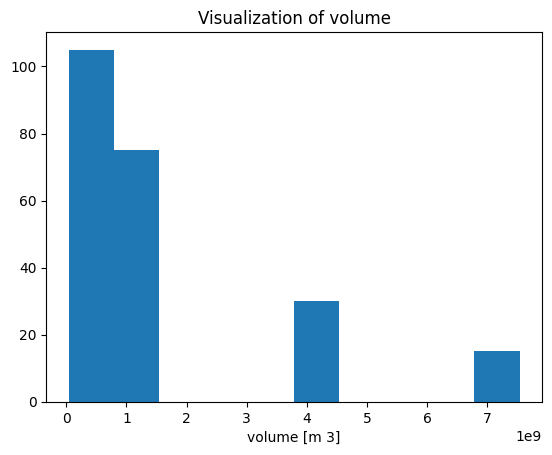

In [2]:
# Plotting one of the variables (if spatial data exists)
# Replace 'variable_name' with a variable from the dataset after inspection
variable_name = 'volume'  # Update this after checking the data structure
if variable_name in data.variables:
    data[variable_name].isel(time=0).plot()  # Adjust the dimension (e.g., 'time') as needed
    plt.title(f"Visualization of {variable_name}")
    plt.show()
else:
    print(f"Variable '{variable_name}' not found in the dataset.")


In [2]:
import netCDF4 as nc
import pandas as pd

# Path to your NetCDF file
file_path = "/home/usman/Music/GeeMap/Results/15_GCM_projections.nc"
output_csv = "/home/usman/Music/GeeMap/Results/GCM_projections_aligned.csv"

# Open the NetCDF file
dataset = nc.Dataset(file_path)

# Identify variables and their dimensions
variables = dataset.variables

# Example: Extract data for time, rgi_id, and a few other variables
# Adjust variable names based on your data
time = variables['time'][:]
rgi_id = variables['rgi_id'][:]

# Example variables with dimensions (time, rgi_id)
aligned_variables = ['volume', 'area', 'length']  # Adjust based on your data

data = {}
data['time'] = time
data['rgi_id'] = rgi_id

# Extract data for the aligned variables
for var_name in aligned_variables:
    variable_data = variables[var_name][:]
    data[var_name] = variable_data.flatten()  # Flatten if multidimensional

# Create DataFrame and save as CSV
df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)

print(f"CSV file created: {output_csv}")


ValueError: All arrays must be of the same length

In [4]:
import netCDF4 as nc
import pandas as pd

# Path to your NetCDF file
file_path = "/home/usman/Music/GeeMap/Results/15_GCM_projections.nc"
output_csv = "/home/usman/Music/GeeMap/Results/GCM_projections_aligned.csv"

# Open the NetCDF file
dataset = nc.Dataset(file_path)

# Inspect variables and their dimensions
variables = dataset.variables
dimensions = dataset.dimensions

# Print variable shapes for debugging
for var_name in variables:
    print(f"Variable '{var_name}' has shape {variables[var_name].shape} and dimensions {variables[var_name].dimensions}")

# Example: Extract data for variables with matching dimensions (time, rgi_id)
# Update based on inspection
time = variables['time'][:]
rgi_id = variables['rgi_id'][:]

# Choose variables with the same shape as (time, rgi_id) or similar
compatible_vars = ['volume', 'area', 'length']  # Adjust based on inspection

# Initialize dictionary to store data
data = {'time': time.flatten()}

# Extract compatible variables
for var_name in compatible_vars:
    variable_data = variables[var_name][:]
    # Ensure the data is 1D or reshape appropriately
    if variable_data.shape[0] == len(time):
        data[var_name] = variable_data.flatten()

# Create DataFrame and save to CSV
df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)

print(f"CSV file created successfully: {output_csv}")


Variable 'volume' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'volume_bsl' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'volume_bwl' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'area' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'length' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'calving' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'calving_rate' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'off_area' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'on_area' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'melt_off_glacier' has shape (3, 5, 87, 15) and dimensions ('SCENARIO', 'GCM', 'time', 'rgi_id')
Variable 'melt